You are working with two complementary datasets describing a large-scale biotechnological production process.

The first dataset (“4000 series operating data”) contains high-frequency sensor measurements collected every 5–15 minutes over several hundred hours for 22 individual batches. It includes 17 process variables such as liquid inflows, gas inflows, pH, off-gas measurements, pressure, and oxygen levels. In total, the dataset contains approximately 1.4 million time-stamped observations. Some values are missing due to sensor limitations or non-operational readings, but all batches are considered representative of normal process operation.

The second dataset contains laboratory measurements recorded approximately every 4 hours for 21 batches. This dataset includes the product concentration values over time, which are used to calculate a yield parameter for each batch. By combining the time-series sensor data with the laboratory product data, it is possible to construct a data-driven model to identify which process variables most strongly influence product yield and to predict the yield of a previously unseen batch.

The operating dataset contains 83,204 time-series observations across 18 columns. Each row corresponds to a timestamped measurement for a specific batch. The Batch column is an integer identifier, Date and time is stored as a datetime variable, and all process variables (LIQUID, GAS, OFFGAS, PRESSURE, pH, and OXYGEN) are continuous numerical features stored as float64. Some missing values are present due to sensor downtime or non-operational readings.

To reduce dimensionality and improve interpretability, related sensor streams were aggregated. The six liquid inflow variables were summed into TOTAL_LIQUID_INFLOW, the four gas inflow variables into TOTAL_GAS_INFLOW, the two off-gas sensors were averaged into TOTAL_OFFGAS, and the two pressure sensors were averaged into MEAN_PRESSURE. This transformation reduces redundancy from multiple sensors measuring similar physical phenomena, mitigates noise between parallel sensors, and simplifies the feature space while preserving the key process information relevant for yield prediction.

Feature Aggregation and Dimensionality Reduction

The operating dataset contains multiple sensor measurements representing similar physical quantities recorded from parallel inflow streams and duplicate sensors. To improve interpretability and reduce redundancy, related variables were aggregated into composite features.

The six liquid inflow variables (LIQUID, LIQUID.1, LIQUID.2, LIQUID.3, LIQUID.4, LIQUID.5) represent separate feed streams entering the same bioreactor. Since the overall system behaviour depends on the total liquid entering the reactor, these variables were summed to create a single feature, TOTAL_LIQUID_INFLOW. Similarly, the four gas inflow variables (GAS, GAS.1, GAS.2, GAS.3) were summed to form TOTAL_GAS_INFLOW, representing the total gas supply to the system.

In contrast, the OFFGAS and PRESSURE variables represent duplicate sensors measuring the same physical process conditions. These were averaged to create TOTAL_OFFGAS and MEAN_PRESSURE, respectively. Averaging improves robustness by reducing measurement noise and mitigating small calibration differences between sensors, while preserving the true underlying process state.

Following aggregation, the original individual sensor columns were removed to reduce dimensionality and multicollinearity. This simplification improves model stability, reduces the risk of overfitting, and ensures that the features more directly reflect the underlying physical processes influencing product yield.

Import data

In [2]:
from applied.data_processing import (
    load_operating_data,
    load_product_data,
    prepare_operating_timeseries,
    batch_time_diagnostics,
    build_features_and_target
)

In [3]:
from pathlib import Path

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

op_df = prepare_operating_timeseries(
    op_df,
    add_tier=False,
    resample_rule="1h"
)

# #need to add denosier and standazing - r we meant to standize before comparing timeseries ?? since we will stadize different depdning on val set ? 
# #need to make index to be able to overlay timeseries and not have them span the year 

op_df

pH      OXYGEN  \
productivity_rank Batch Date and time                               
1                 4041  2020-03-18 09:00:00  6.165000    8.820000   
                        2020-03-18 10:00:00  5.897500    7.090000   
                        2020-03-18 11:00:00  5.787500    8.435000   
                        2020-03-18 12:00:00  5.795000   38.120000   
                        2020-03-18 13:00:00  5.802500    8.602500   
...                                               ...         ...   
22                4053  2021-05-25 17:00:00  5.801667   13.085000   
                        2021-05-25 18:00:00  5.791667   10.825000   
                        2021-05-25 19:00:00  5.803333   12.715833   
                        2021-05-25 20:00:00  5.870833   68.421667   
                        2021-05-25 21:00:00  5.760000  111.818750   

                                             TOTAL_LIQUID_INFLOW  \
productivity_rank Batch Date and time                              
1                 4041  2020-03-18 09:00:00         15994.080000   
                        2020-03-18 10:00:00         16277.535000   
                        2020-03-18 11:00:00         18091.965000   
                        2020-03-18 12:00:00         18324.007500   
                        2020-03-18 13:00:00         18315.392500   
...                                                          ...   
22                4053  2021-05-25 17:00:00         24041.537500   
                        2021-05-25 18:00:00         23967.733333   
                        2021-05-25 19:00:00         23774.552500   
                        2021-05-25 20:00:00         23788.894167   
                        2021-05-25 21:00:00         21133.936250   

                                             TOTAL_GAS_INFLOW  MEAN_OFFGAS  \
productivity_rank Batch Date and time                                        
1                 4041  2020-03-18 09:00:00       7586.485000    28.050000   
                        2020-03-18 10:00:00       7624.742500    29.657500   
                        2020-03-18 11:00:00       8019.370000    33.430000   
                        2020-03-18 12:00:00       8131.182500    31.398750   
                        2020-03-18 13:00:00       8169.685000    18.198750   
...                                                       ...          ...   
22                4053  2021-05-25 17:00:00      12223.495833     3.422083   
                        2021-05-25 18:00:00      12232.390833     3.423333   
                        2021-05-25 19:00:00      12229.294167     3.429167   
                        2021-05-25 20:00:00      12187.012500     3.042083   
                        2021-05-25 21:00:00      11354.962500     2.587500   

                                             MEAN_PRESSURE  
productivity_rank Batch Date and time                       
1                 4041  2020-03-18 09:00:00       3.357500  
                        2020-03-18 10:00:00       3.413750  
                        2020-03-18 11:00:00       3.541250  
                        2020-03-18 12:00:00       3.558750  
                        2020-03-18 13:00:00       3.628750  
...                                                    ...  
22                4053  2021-05-25 17:00:00       3.636250  
                        2021-05-25 18:00:00       3.633750  
                        2021-05-25 19:00:00       3.608333  
                        2021-05-25 20:00:00       3.591667  
                        2021-05-25 21:00:00       3.546875  

[14393 rows x 6 columns]

In [4]:
sensor_cols = [
    "pH",
    "OXYGEN",
    "TOTAL_LIQUID_INFLOW",
    "TOTAL_GAS_INFLOW",
    "MEAN_OFFGAS",
    "MEAN_PRESSURE"
]

op_df[sensor_cols].isna().sum()


pH                     148
OXYGEN                 148
TOTAL_LIQUID_INFLOW    114
TOTAL_GAS_INFLOW       114
MEAN_OFFGAS            148
MEAN_PRESSURE          148
dtype: int64

In [5]:
diag = batch_time_diagnostics(op_df)

diag

,,Start,End,Duration_hours,Duration_days,Calendar_days_spanned,Expected_samples,Actual_samples,Missing_samples,Percent_missing
productivity_rank,Batch,,,,,,,,,
1,4041,2020-03-18 09:00:00,2020-04-15 23:00:00,686.0,28.583333,29,687,687,0,0.0
2,4043,2020-06-09 19:00:00,2020-06-28 16:00:00,453.0,18.875000,20,454,454,0,0.0
3,4047,2020-10-13 23:00:00,2020-11-13 20:00:00,741.0,30.875000,32,742,742,0,0.0
4,4040,2020-02-08 11:00:00,2020-03-08 04:00:00,689.0,28.708333,30,690,690,0,0.0
5,4042,2020-04-24 00:00:00,2020-05-29 23:00:00,863.0,35.958333,36,864,864,0,0.0
6,4046,2020-08-28 01:00:00,2020-10-04 13:00:00,900.0,37.500000,38,901,901,0,0.0
7,4045,2020-07-28 20:00:00,2020-08-11 16:00:00,332.0,13.833333,15,333,333,0,0.0
8,4052,2021-03-10 21:00:00,2021-04-13 01:00:00,796.0,33.166667,35,797,797,0,0.0
9,4034,2019-07-02 13:00:00,2019-08-03 23:00:00,778.0,32.416667,33,779,779,0,0.0


In [6]:
op_df["relative_step"] = op_df.groupby("Batch").cumcount()

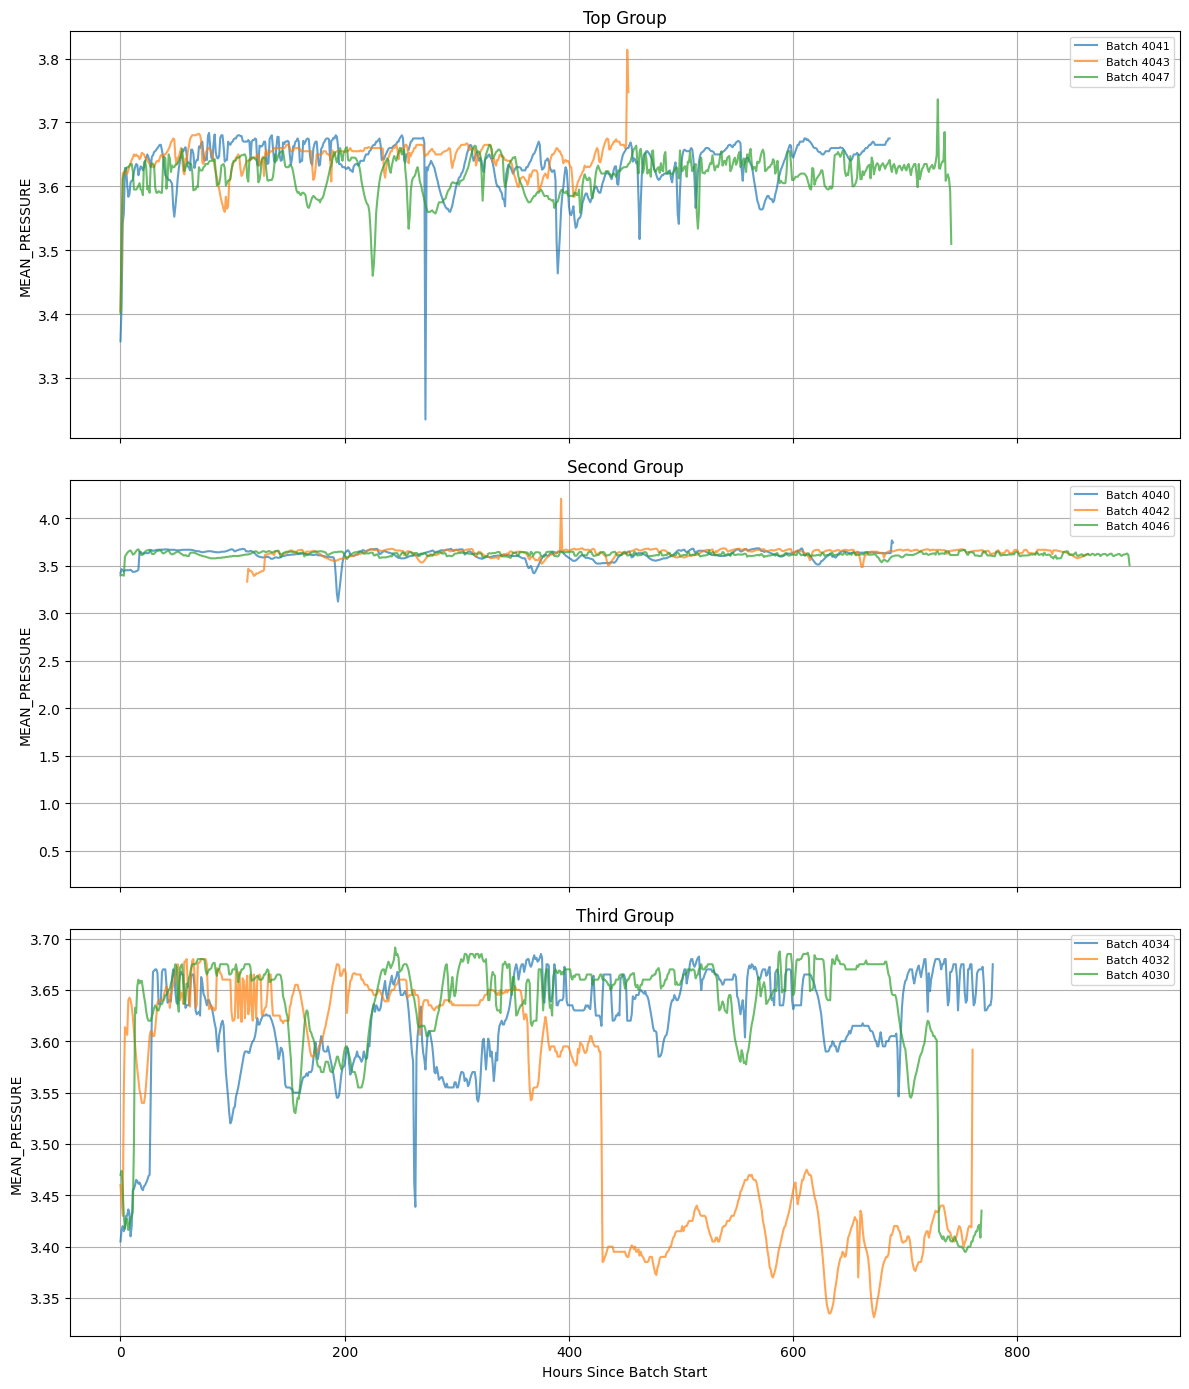

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------
# Prepare Data
# -----------------------

df_plot = op_df.reset_index()

# -----------------------
# Define Groups
# -----------------------

top_plot    = [4041, 4043, 4047]
second_plot = [4040, 4042, 4046]
third_plot  = [4034, 4032, 4030]

groups = [top_plot, second_plot, third_plot]
titles = ["Top Group", "Second Group", "Third Group"]

# -----------------------
# Plot
# -----------------------

feature = 'MEAN_PRESSURE'

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

for ax, batch_group, title in zip(axes, groups, titles):

    for batch_id in batch_group:

        batch_data = (
            df_plot[df_plot["Batch"] == batch_id]
            .sort_values("relative_step")
        )

        ax.plot(
            batch_data["relative_step"],
            batch_data[feature],
            label=f"Batch {batch_id}",
            alpha=0.7
        )

    ax.set_title(title)
    ax.set_ylabel(feature)
    ax.legend(fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel("Hours Since Batch Start")

plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor

from applied.data_processing import (
    load_operating_data,
    load_product_data,
    build_features_and_target
)


# ======================================================
# Load Data
# ======================================================

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

X, y = build_features_and_target(op_df, prod_df, resample_rule="1D")


# ======================================================
# Align & Clean
# ======================================================

y = y.reindex(X.index)

mask = y.notna()
X_model = X.loc[mask]
y_model = y.loc[mask]


print("Number of batches:", len(y_model))
print("Mean productivity:", y_model.mean())
print("Std productivity:", y_model.std())

Number of batches: 21
Mean productivity: 611.4257337418247
Std productivity: 36.88367330629687


In [9]:
from applied.models import evaluate_models

results = evaluate_models(X, y)


Model Comparison:
            Model       MAE      RMSE        R²  Relative MAE (%)  Bootstrap R² Mean  Bootstrap R² Std  R² 95% CI Lower  R² 95% CI Upper
    Random Forest 27.856826 37.197364 -0.067936          4.556044          -0.102933          0.178312        -0.498970         0.249762
    PLS (2 comps) 39.460118 46.842935 -0.693593          6.453788          -0.958083          0.729455        -2.883325        -0.060433
            Ridge 51.228298 64.937393 -2.254698          8.378499          -2.801719          1.635897        -7.120253        -0.839014
Linear Regression 57.158096 71.832790 -2.982598          9.348330          -3.700002          2.195859        -9.333319        -1.078208


In [10]:
results = evaluate_models(X_model[["offgas_range", "oxy_range", "oxy_slope"]], y_model)


Model Comparison:
            Model       MAE      RMSE       R²  Relative MAE (%)  Bootstrap R² Mean  Bootstrap R² Std  R² 95% CI Lower  R² 95% CI Upper
            Ridge 20.798101 27.368242 0.421884          3.401574           0.338425          0.260543        -0.304130         0.672600
Linear Regression 21.111167 27.439003 0.418891          3.452777           0.329306          0.281568        -0.362301         0.687654
    PLS (2 comps) 21.311223 27.500032 0.416303          3.485497           0.329381          0.274327        -0.346842         0.673838
    Random Forest 28.922788 33.056998 0.156572          4.730384           0.060279          0.234011        -0.538589         0.378983


In [11]:
results = evaluate_models(X_model[['liquid_range', 'offgas_std', 'oxy_std', 'gas_late_mean', 'oxy_auc']], y_model)


Model Comparison:
            Model       MAE      RMSE       R²  Relative MAE (%)  Bootstrap R² Mean  Bootstrap R² Std  R² 95% CI Lower  R² 95% CI Upper
Linear Regression 17.283896 22.972611 0.592674          2.826819           0.534665          0.210562         0.012818         0.825770
            Ridge 19.224731 23.981440 0.556114          3.144246           0.497424          0.208336         0.008043         0.790340
    PLS (2 comps) 26.082121 32.112908 0.204060          4.265787           0.085177          0.404743        -0.795952         0.562663
    Random Forest 26.802549 34.823441 0.064025          4.383615           0.012365          0.195322        -0.431860         0.357421


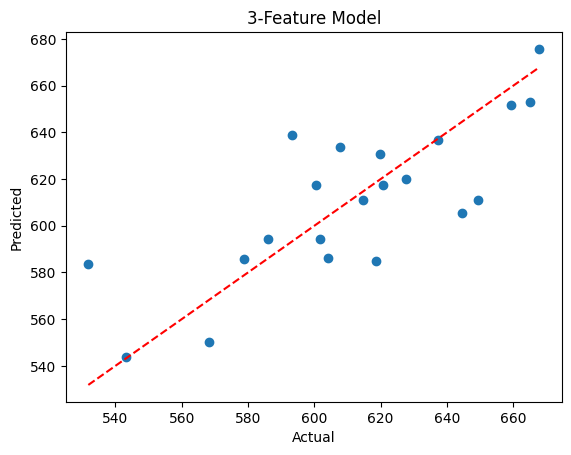

In [12]:
features = ['liquid_range', 'offgas_std', 'oxy_std', 'gas_late_mean', 'oxy_auc']

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

preds = cross_val_predict(pipe, X_model[features], y_model, cv=LeaveOneOut())

import matplotlib.pyplot as plt
plt.scatter(y_model, preds)
plt.plot([y_model.min(), y_model.max()],
         [y_model.min(), y_model.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("3-Feature Model")
plt.show()


pip install tsfresh

pip install 

sklearn.feature_selection

pip install mlxtend

In [6]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


loo = LeaveOneOut()

results = []

for col in X_model.columns:

    X_single = X_model[[col]]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    preds = cross_val_predict(pipe, X_single, y_model, cv=loo)

    r2 = r2_score(y_model, preds)
    mae = np.mean(np.abs(y_model - preds))
    rmse = np.sqrt(mean_squared_error(y_model, preds))

    results.append({
        "Feature": col,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse
    })


results_df = pd.DataFrame(results).sort_values("R²", ascending=False)

print("\nSingle-Feature LOOCV Results:")
print(results_df.head(15).to_string(index=False))



Single-Feature LOOCV Results:
          Feature        R²       MAE      RMSE
     offgas_range  0.164137 28.191783 32.908418
       offgas_std  0.073213 28.843465 34.652103
        oxy_range  0.063673 26.919965 34.829986
       liquid_std -0.004074 29.114126 36.068026
     liquid_range -0.007254 28.083419 36.125099
     offgas_slope -0.015072 28.706966 36.265017
   oxy_early_mean -0.059511 27.959756 37.050343
liquid_early_mean -0.071727 30.566290 37.263319
   pressure_range -0.085547 28.439416 37.502814
oxy_high_fraction -0.090309 29.548498 37.584976
     pressure_std -0.092296 28.498003 37.619210
          oxy_std -0.099152 29.547703 37.737091
     ph_late_mean -0.102300 29.675348 37.791098
         ph_range -0.102465 29.181245 37.793916
 liquid_late_mean -0.103354 29.781777 37.809160


In [26]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

selected_features = ["liquid_range"]
remaining_features = list(X_model.columns)

remaining_features.remove("offgas_range")

def evaluate(features):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    preds = cross_val_predict(pipe, X_model[features], y_model, cv=loo)
    return r2_score(y_model, preds)

current_r2 = evaluate(selected_features)

print("Start:", selected_features, "R²:", current_r2)

while len(selected_features) < 5:
    best_feature = None
    best_r2 = current_r2
    
    for f in remaining_features:
        test_features = selected_features + [f]
        r2 = evaluate(test_features)
        if r2 > best_r2:
            best_r2 = r2
            best_feature = f
    
    if best_feature is None:
        break
    
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    current_r2 = best_r2
    
    print("Added:", best_feature, "→ R²:", current_r2)

print("\nFinal Feature Set:", selected_features)


Start: ['liquid_range'] R²: -0.007254118134864873
Added: offgas_std → R²: 0.19949118507614783
Added: oxy_std → R²: 0.30944413407021687
Added: gas_late_mean → R²: 0.3514844450196901
Added: oxy_auc → R²: 0.5926744208187364

Final Feature Set: ['liquid_range', 'offgas_std', 'oxy_std', 'gas_late_mean', 'oxy_auc']


In [31]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression

rfecv = RFECV(
    estimator=LinearRegression(),
    cv=5,
    scoring="r2"
)

rfecv.fit(X_model, y_model)

selected = X_model.columns[rfecv.support_]
selected

Index(['oxy_high_fraction', 'offgas_slope', 'pressure_early_mean',
       'pressure_late_mean', 'pressure_range'],
      dtype='str')

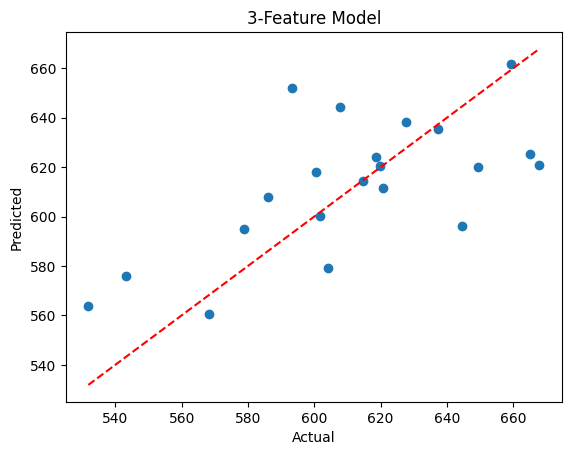

In [4]:
features = ['offgas_range', 'oxy_range', 'oxy_slope']

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

preds = cross_val_predict(pipe, X_model[features], y_model, cv=LeaveOneOut())

import matplotlib.pyplot as plt
plt.scatter(y_model, preds)
plt.plot([y_model.min(), y_model.max()],
         [y_model.min(), y_model.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("3-Feature Model")
plt.show()


In [5]:
pipe.fit(X_model[features], y_model)

coefs = pd.Series(
    pipe.named_steps["model"].coef_,
    index=features
)

print(coefs)

offgas_range   -23.716760
oxy_range       14.488378
oxy_slope       -7.958173
dtype: float64


In [14]:
import math
p = X_model.shape[1]
print("Features:", p)
print("Combinations:", math.comb(p, 3))

Features: 52
Combinations: 22100


In [15]:
import itertools
import numpy as np
import pandas as pd
import math
import sys

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

loo = LeaveOneOut()

rows = []
cols = list(X_model.columns)

total = math.comb(len(cols), 3)
print("Total combinations:", total)

for i, trio in enumerate(itertools.combinations(cols, 3), 1):
    preds = cross_val_predict(pipe, X_model[list(trio)], y_model, cv=loo)
    r2 = r2_score(y_model, preds)
    rows.append((trio, r2))

    # print every 50 iterations
    if i % 50 == 0 or i == total:
        progress = 100 * i / total
        print(f"Progress: {progress:.1f}% ({i}/{total})")
        sys.stdout.flush()

best = sorted(rows, key=lambda x: x[1], reverse=True)[:20]
best_df = pd.DataFrame(best, columns=["features", "R2"])
print("\nTop 20 combinations:")
print(best_df.to_string(index=False))


Total combinations: 22100
Progress: 0.2% (50/22100)
Progress: 0.5% (100/22100)
Progress: 0.7% (150/22100)
Progress: 0.9% (200/22100)
Progress: 1.1% (250/22100)
Progress: 1.4% (300/22100)
Progress: 1.6% (350/22100)
Progress: 1.8% (400/22100)
Progress: 2.0% (450/22100)
Progress: 2.3% (500/22100)
Progress: 2.5% (550/22100)
Progress: 2.7% (600/22100)


KeyboardInterrupt: 

In [13]:
import itertools
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X_np = X_model.values
y_np = y_model.values
feature_names = list(X_model.columns)

n = len(y_np)

results = []

for trio in itertools.combinations(range(X_np.shape[1]), 3):

    preds = np.zeros(n)

    for i in range(n):
        # LOOCV split
        train_idx = np.arange(n) != i
        test_idx = ~train_idx

        X_train = X_np[train_idx][:, trio]
        X_test = X_np[test_idx][:, trio]
        y_train = y_np[train_idx]

        # Impute
        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(X_train)
        X_test = imputer.transform(X_test)

        # Scale
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Fit
        model = LinearRegression()
        model.fit(X_train, y_train)

        preds[i] = model.predict(X_test)[0]

    r2 = r2_score(y_np, preds)

    results.append(([feature_names[i] for i in trio], r2))

results_df = (
    pd.DataFrame(results, columns=["Features", "R2"])
    .sort_values("R2", ascending=False)
)

print(results_df.head(15).to_string(index=False))


KeyboardInterrupt: 

In [11]:
from pathlib import Path

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

X, y = build_features_and_target(op_df, prod_df)

In [54]:
from pathlib import Path

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

X, y = build_features_and_target(op_df, prod_df, resample_rule='1D')

In [ ]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score


from pathlib import Path

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

X, y = build_features_and_target(op_df, prod_df, resample_rule='1D')

# -----------------------------
# Align X and y properly
# -----------------------------

# Ensure y is a pandas Series aligned to X
y = y.loc[X.index]

# Drop rows with missing target
mask = y.notna()
X_model = X.loc[mask]
y_model = y.loc[mask]


# -----------------------------
# Define pipeline
# -----------------------------

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,      # more trees for stability
        max_depth=None,        # let RF decide
        min_samples_leaf=2,    # regularization for small data
        random_state=42
    ))
])


# -----------------------------
# LOOCV Evaluation
# -----------------------------

loo = LeaveOneOut()

scores_mae = cross_val_score(
    pipe,
    X_model,
    y_model,
    cv=loo,
    scoring="neg_mean_absolute_error"
)

mae = -scores_mae.mean()

print("LOOCV MAE:", mae)
print("Mean productivity:", y_model.mean())
print("Relative MAE (%):", 100 * mae / y_model.mean())


LOOCV MAE: 26.132893681907962
Mean productivity: 611.4257337418247
Relative MAE (%): 4.27409123295792


In [50]:
pipe.fit(X_model, y_model)

importances = pipe.named_steps["model"].feature_importances_
feature_names = X_model.columns

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

print(importance_df)


              feature  importance
14    offgas_diff_std    0.295570
9            gas_mean    0.211554
15      pressure_mean    0.113678
13       offgas_slope    0.053592
12        offgas_mean    0.051753
1        liquid_slope    0.047215
3     ph_mean_abs_dev    0.039842
7           oxy_slope    0.030866
5         ph_diff_std    0.024981
11       gas_diff_std    0.024413
0         liquid_mean    0.019496
8        oxy_diff_std    0.019437
2     liquid_diff_std    0.017464
16     pressure_slope    0.013975
6            oxy_mean    0.011764
10          gas_slope    0.009332
4            ph_slope    0.008258
17  pressure_diff_std    0.006811


In [51]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict

preds = cross_val_predict(pipe, X_model, y_model, cv=LeaveOneOut())

print("LOOCV R2:", r2_score(y_model, preds))

LOOCV R2: 0.0483241283080077


In [52]:
print("Min productivity:", y_model.min())
print("Max productivity:", y_model.max())
print("Std productivity:", y_model.std())


Min productivity: 531.863117199551
Max productivity: 667.8202189380673
Std productivity: 36.88367330629687
